<div style="background:linear-gradient(135deg,#172554 0%,#1e40af 55%,#3b82f6 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#bfdbfe;font-weight:700;text-transform:uppercase">Chapter 72 · Estimation &amp; Confidence Intervals</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Margin of Error 📐</div>
  <div style="font-size:15px;color:#eff6ff;max-width:740px;line-height:1.6">The margin of error is the +/- you see in every poll, the half-width of a confidence interval. We unpack what drives it (confidence, variability, and sample size), watch it shrink like 1/sqrt(n), and report a real customer survey the right way.</div>
  <div style="margin-top:16px;font-size:13px;color:#bfdbfe">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
BLUE="#2563eb"; DEEP="#1d4ed8"; LIGHT="#60a5fa"; INK="#1a2138"; GRID="#e6e9f2"; GREEN="#059669"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
rng = np.random.default_rng(72)

<div style="background:#eef2ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1d4ed8;letter-spacing:1px">DEMO 1 · WHAT THE MARGIN OF ERROR IS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The +/- half-width of a confidence interval</div>
<div style="color:#4a5578;margin-top:6px">Every confidence interval is estimate +/- margin. That margin is the margin of error: MoE = z * SE. It is the number a poll means by '+/- 3 points'.</div>
</div>

In [2]:
phat, n = 0.52, 1000; z = stats.norm.ppf(0.975)
se = np.sqrt(phat*(1-phat)/n)
moe = z*se
print(f"estimate p-hat = {phat:.0%}, SE = {se:.4f}")
print(f"margin of error (95%) = z*SE = {moe:.4f} = +/- {moe*100:.1f} percentage points")
print(f"the interval is [{(phat-moe)*100:.1f}%, {(phat+moe)*100:.1f}%], reported as {phat:.0%} +/- {moe*100:.0f}%")

estimate p-hat = 52%, SE = 0.0158
margin of error (95%) = z*SE = 0.0310 = +/- 3.1 percentage points
the interval is [48.9%, 55.1%], reported as 52% +/- 3%


The margin of error is just the half-width of the interval, z&#183;SE. A poll that says "52% &#177; 3%" is reporting an estimate of 52% with a margin of error of 3 percentage points at (usually) 95% confidence.

<div style="background:#eef2ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1d4ed8;letter-spacing:1px">DEMO 2 · THE THREE DRIVERS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Confidence, variability, and sample size</div>
<div style="color:#4a5578;margin-top:6px">MoE = z * sqrt(p(1-p)/n) for a proportion. It rises with the confidence level (bigger z), rises with variability (largest at p=0.5), and falls with sample size n.</div>
</div>

In [3]:
n = 1000
print("Confidence level (variability fixed at p=0.5, n=1000):")
for conf in [0.90, 0.95, 0.99]:
    zz = stats.norm.ppf(0.5+conf/2); print(f"  {conf:.0%}: z={zz:.3f} -> MoE = +/- {zz*np.sqrt(0.25/n)*100:.2f} pts")
print("\nVariability (95%, n=1000):")
for p in [0.1, 0.3, 0.5]:
    print(f"  p={p}: MoE = +/- {z*np.sqrt(p*(1-p)/n)*100:.2f} pts   (largest at p=0.5)")

Confidence level (variability fixed at p=0.5, n=1000):
  90%: z=1.645 -> MoE = +/- 2.60 pts
  95%: z=1.960 -> MoE = +/- 3.10 pts
  99%: z=2.576 -> MoE = +/- 4.07 pts

Variability (95%, n=1000):
  p=0.1: MoE = +/- 1.86 pts   (largest at p=0.5)
  p=0.3: MoE = +/- 2.84 pts   (largest at p=0.5)
  p=0.5: MoE = +/- 3.10 pts   (largest at p=0.5)


Three knobs. <strong>Higher confidence</strong> widens the margin (99% needs more room than 90%). <strong>More variability</strong> widens it, and p(1&#8722;p) is largest at p = 0.5, the conservative worst case pollsters assume. <strong>More data</strong> shrinks it, the only knob that improves precision without costing confidence.

<div style="background:#eef2ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1d4ed8;letter-spacing:1px">DEMO 3 · THE 1/sqrt(n) LAW</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Quadruple the sample to halve the margin</div>
<div style="color:#4a5578;margin-top:6px">Because MoE is proportional to 1/sqrt(n), precision is expensive: each halving of the margin needs four times the sample. We trace the curve.</div>
</div>

n=  100: MoE = +/- 9.80 pts
n=  250: MoE = +/- 6.20 pts
n=  500: MoE = +/- 4.38 pts
n= 1000: MoE = +/- 3.10 pts
n= 2000: MoE = +/- 2.19 pts
n= 4000: MoE = +/- 1.55 pts
n= 8000: MoE = +/- 1.10 pts

n 1000 -> 4000 (4x) changes MoE from 3.10 to 1.55 pts (halved)


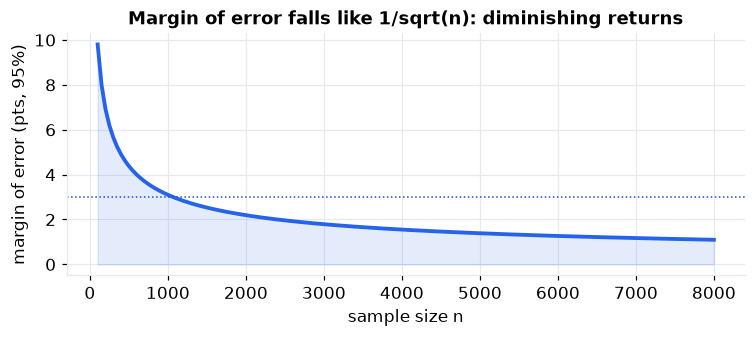

In [4]:
ns = np.array([100,250,500,1000,2000,4000,8000])
moes = z*np.sqrt(0.25/ns)
for nn,m in zip(ns,moes): print(f"n={nn:>5}: MoE = +/- {m*100:.2f} pts")
print(f"\nn 1000 -> 4000 (4x) changes MoE from {z*np.sqrt(0.25/1000)*100:.2f} to {z*np.sqrt(0.25/4000)*100:.2f} pts (halved)")
fig,ax=plt.subplots(figsize=(7,3.2))
grid=np.arange(100,8001,50)
ax.plot(grid, z*np.sqrt(0.25/grid)*100, color=BLUE, lw=2.5)
ax.fill_between(grid, z*np.sqrt(0.25/grid)*100, color=BLUE, alpha=0.12)
ax.axhline(3, color=DEEP, ls=":", lw=1); ax.set_xlabel("sample size n"); ax.set_ylabel("margin of error (pts, 95%)")
ax.set_title("Margin of error falls like 1/sqrt(n): diminishing returns"); plt.tight_layout(); plt.show()

The curve falls steeply then flattens. Getting from &#177;6 to &#177;3 points is cheap; getting from &#177;3 to &#177;1.5 costs four times as much again. This is why the classic national poll lands near n = 1,000 (about &#177;3%): it is the sweet spot where extra precision stops being worth the cost.

<div style="background:#ecfdf5;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">REAL-WORLD EXAMPLE · CUSTOMER SURVEY</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Reporting a satisfaction result the right way</div>
<div style="color:#4a5578;margin-top:6px"></div>
</div>

A company surveyed <strong>900 customers</strong> (`ch72_customer_survey.xlsx`) and wants to report the share who would recommend it, with a proper margin of error, the way a press release or board deck should.

In [5]:
try:    survey = pd.read_excel("../../data/ch72_customer_survey.xlsx", sheet_name="Responses")
except FileNotFoundError: survey = pd.read_excel(BASE+"ch72_customer_survey.xlsx", sheet_name="Responses")
print("loaded:", survey.shape)
rec = survey["would_recommend"]
n = len(rec); phat = rec.mean(); se = np.sqrt(phat*(1-phat)/n); z = stats.norm.ppf(0.975)
moe = z*se
print(f"n = {n} respondents")
print(f"would recommend: p-hat = {phat:.1%}")
print(f"margin of error (95%) = +/- {moe*100:.2f} percentage points")
print(f"\nHEADLINE: {phat*100:.0f}% would recommend, +/- {moe*100:.1f} points (95% confidence)")
print(f"i.e. the true rate is very likely between {(phat-moe)*100:.1f}% and {(phat+moe)*100:.1f}%")

loaded: (900, 5)
n = 900 respondents
would recommend: p-hat = 64.3%
margin of error (95%) = +/- 3.13 percentage points

HEADLINE: 64% would recommend, +/- 3.1 points (95% confidence)
i.e. the true rate is very likely between 61.2% and 67.5%


In [6]:
print("How the margin would change:\n")
print("By confidence level (this n):")
for conf in [0.90,0.95,0.99]:
    zz=stats.norm.ppf(0.5+conf/2); print(f"  {conf:.0%}: +/- {zz*se*100:.2f} pts")
print("\nBy sample size (95%):")
for nn in [300, 900, 2500]:
    print(f"  n={nn:>5}: +/- {z*np.sqrt(phat*(1-phat)/nn)*100:.2f} pts")

How the margin would change:

By confidence level (this n):
  90%: +/- 2.63 pts
  95%: +/- 3.13 pts
  99%: +/- 4.11 pts

By sample size (95%):
  n=  300: +/- 5.42 pts
  n=  900: +/- 3.13 pts
  n= 2500: +/- 1.88 pts


The honest headline is <strong>"64% would recommend, &#177;3.1 points at 95% confidence."</strong> Reporting just "64%" hides the uncertainty; reporting the margin makes the claim defensible. The follow-up table shows the levers: a 99% guarantee widens the margin to about &#177;4 points, and to halve the margin the company would need roughly four times the respondents.

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:22px 26px;font-family:Inter,sans-serif">
<div style="font-size:19px;font-weight:800;color:#1a2138">✅ Margin of error</div>
<div style="color:#4a5578;line-height:1.8;margin-top:8px">The margin of error is z*SE, the +/- half-width of a confidence interval. It grows with the confidence level and with variability (worst at p=0.5), and shrinks like 1/sqrt(n) (quadruple the sample to halve it). On a real 900-person survey, 64% would recommend with a margin of +/-3.1 points at 95% confidence, the right way to report any rate.</div>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:16px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>